In [ ]:
#!pip install astra-toolbox

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from scipy import io
import astra
import time

from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
directory = '/content/gdrive/MyDrive/PUB/Otimização Não Linear/small/'


--- Realizando pré-processamento ---
Sinograma reduzido: (1500, 512)


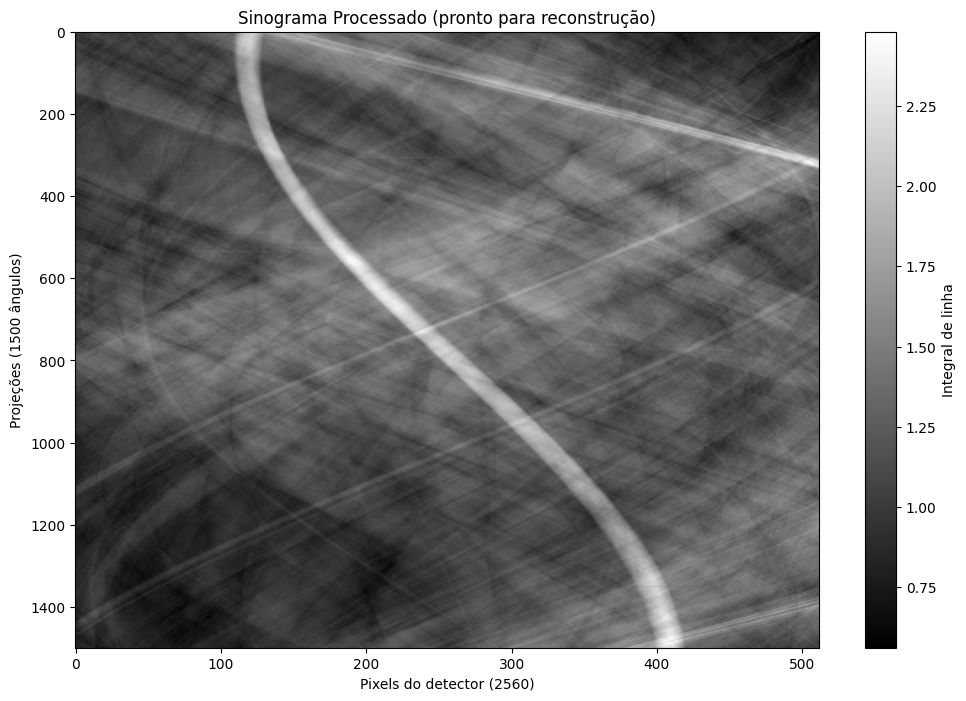

In [ ]:
# 1. Carregar o arquivo .mat
mat_data = io.loadmat(directory + 'slice_1080_data.mat')

# Extrair os dados e transpor para o formato correto: (n_angles, n_detector)
X_dark = mat_data['X_dark'].T # (dark_images, pixels)
X_flat = mat_data['X_flat'].T # (flat_images, pixels)
X_proj = mat_data['X_proj'].T # (projections, pixels)

# 4. Pré-processamento (correção de dark e flat)
print("\n--- Realizando pré-processamento ---")

# Calcular médias ao longo das imagens (axis=0)
dark_mean = np.mean(X_dark, axis=0)      # Média dos dark fields (perfil de 2560 pixels)
flat_mean = np.mean(X_flat, axis=0)      # Média dos flat fields (perfil de 2560 pixels)

# Corrigir cada projeção: I_corrected = (I_raw - dark) / (flat - dark)
# Adicionar pequeno valor para evitar divisão por zero
denominator = flat_mean - dark_mean
denominator = np.where(denominator < 1e-6, 1e-6, denominator)

sinogram_corrected = np.zeros_like(X_proj, dtype=np.float32)

for i in range(X_proj.shape[0]):
    sinogram_corrected[i] = (X_proj[i] - dark_mean) / denominator

# Clip para evitar valores negativos ou muito pequenos
sinogram_corrected = np.clip(sinogram_corrected, 1e-6, None)

# 5. Aplicar transformada -log para converter em integrais de linha
# Aplicar -log, garantindo valores positivos
sinogram_processed = -np.log(np.maximum(sinogram_corrected, 1e-8))

# 6. Configurar geometria para reconstrução
n_detector = X_proj.shape[1]      # Número de pixels no detector: 2560
n_angles = X_proj.shape[0]        # Número de projeções: 1500

# Ângulos: de 0 a 180 graus (π radianos)
# Nota: 1500 projeções de 0 a 180 graus (excluindo 180)
angles = np.linspace(0, np.pi, n_angles, endpoint=False)

# Para reconstrução, podemos reduzir a resolução se necessário
# 2560x2560 pode ser muito grande! Vamos reduzir para 512x512 para teste
recon_size = 512

# Subamostrar o sinograma para tamanho menor
sinogram_small = resize(sinogram_processed, (n_angles, recon_size), preserve_range=True)
b = sinogram_small
print(f"Sinograma reduzido: {b.shape}")

# Visualizar sinograma processado
plt.figure(figsize=(12, 8))
plt.imshow(b, cmap='gray', aspect='auto')
plt.title('Sinograma Processado (pronto para reconstrução)')
plt.xlabel('Pixels do detector (2560)')
plt.ylabel('Projeções (1500 ângulos)')
plt.colorbar(label='Integral de linha')
plt.show()

In [ ]:
# Geometria para ASTRA com tamanho reduzido
vol_geom = astra.create_vol_geom(recon_size, recon_size)
proj_geom = astra.create_proj_geom('parallel', 1.0, recon_size, angles)

# Criar projetor
projector_id = astra.create_projector('linear', proj_geom, vol_geom)

In [ ]:
# 7. Definir operadores para seu algoritmo
def A(x):
    _, sinogram = astra.create_sino(x, projector_id)
    return sinogram

def AT(y):
    _, backproj = astra.create_backprojection(y, projector_id)
    return backproj

# 8. Seu método de gradiente descendente
def grad(x):
    Ax = A(x)
    return AT(Ax - b)

def exact_step(x):
    g = grad(x)
    Ag = A(g)
    ATAg = AT(Ag)
    num = np.sum(g * g)
    den = np.sum(g * ATAg)
    return num / den if den > 0 else 0.01

def descent_grad(x0=None, Lambda=None, iters=10, verbose=True):
    if x0 is None:
        x = np.zeros((recon_size, recon_size), dtype=np.float32)
    else:
        x = x0.copy()

    history = []
    errors = []

    for i in range(iters):
        if Lambda is None:
            step = exact_step(x)
        else:
            step = Lambda

        x = x - step * grad(x)

        # Calcular erro a cada iteração
        if verbose and i % 5 == 0:
            Ax = A(x)
            error = 0.5 * np.sum((Ax - b)**2)
            errors.append(error)
            print(f"Iteração {i:3d}: erro = {error:.2e}, passo = {step:.4f}")

    return x, errors


--- Iniciando reconstrução (isso pode levar alguns minutos) ---
Iteração   0: erro = 4.14e+04, passo = 0.0000
Iteração   5: erro = 1.68e+04, passo = 0.0000
Tempo de reconstrução: 234.90 segundos


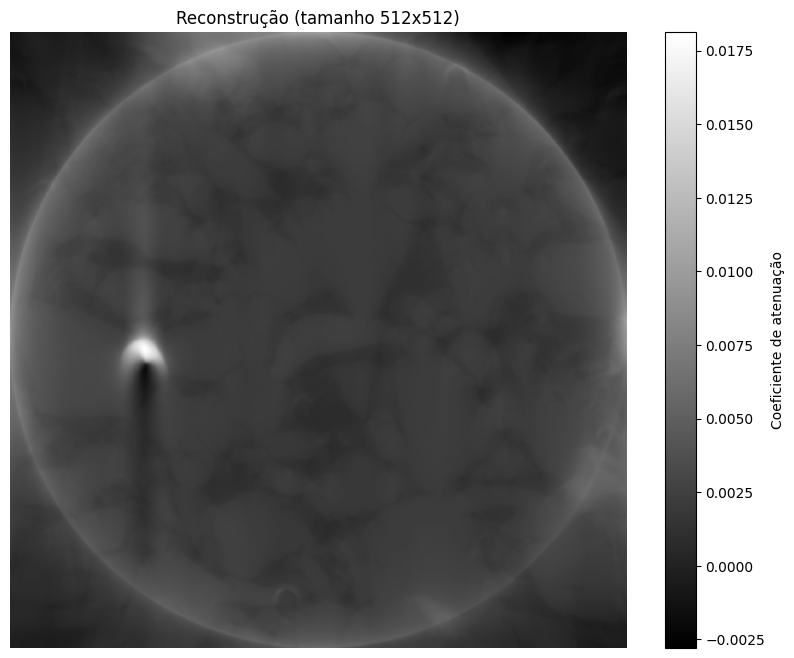

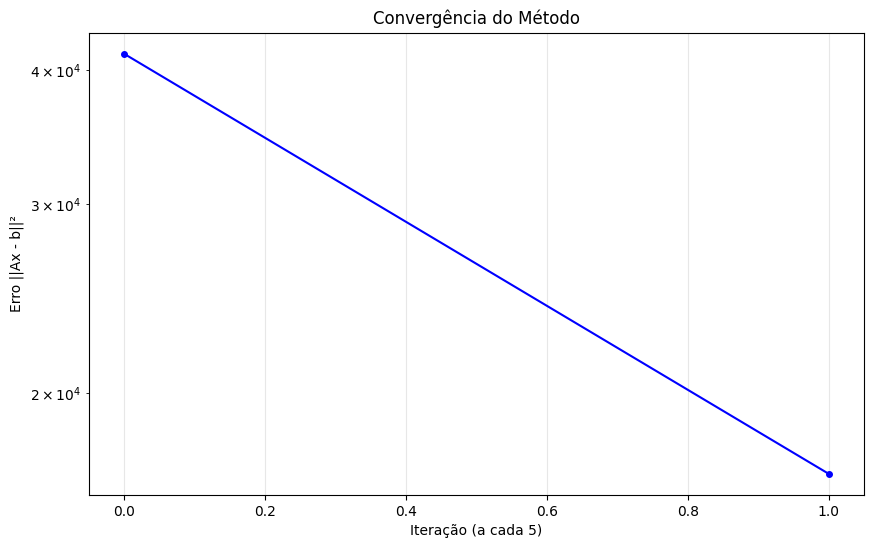

In [ ]:
# 9. Executar reconstrução
print("\n--- Iniciando reconstrução (isso pode levar alguns minutos) ---")
start = time.time()
reconstruction, errors = descent_grad(iters=10)
end = time.time()
print(f"Tempo de reconstrução: {end - start:.2f} segundos")

# Visualizar resultado
plt.figure(figsize=(10, 8))
plt.imshow(reconstruction, cmap='gray')
plt.title(f'Reconstrução (tamanho {recon_size}x{recon_size})')
plt.colorbar(label='Coeficiente de atenuação')
plt.axis('off')
plt.show()

# Mostrar evolução do erro
plt.figure(figsize=(10, 6))
plt.semilogy(errors, 'b-o', markersize=4)
plt.xlabel('Iteração (a cada 5)')
plt.ylabel('Erro ||Ax - b||²')
plt.title('Convergência do Método')
plt.grid(True, alpha=0.3)
plt.show()